# Homework 4 - Computing Point-in-Time Residual Returns
In this homework, we will use regressions to compute beta-adjusted "residual" returns in a point-in-time fashion suitable for backtesting / live trading.


1. Download Daily Bars for FB, AAPL, AMZN, NFLX, GOOGL and QQQ from yahoo finance starting 2016-01-01. Use the Adj Close to compute daily returns.
2. Now, let's compute the beta of FB, AAPL, AMZN, NFLX, GOOGL using QQQ as our benchmark. You can think of this as the beta these stocks have to their industry (tech). In practice,  we have to use some lookback window to compute the beta. Let's use 252 (1 year, excluding wknds/holidays). So, for each day, the betas should be computed using the most recent 252 data points.
3. Using the betas, compute an "alpha" on each day. This is also known as a "residual return".
4. Compare the volatility of the residual returns to that of the original returns. What do you notice?
5. Compare the pairwise correlations of the residual returns to that of the original returns. What do you notice?
6. Compute the information ratio for each of these stocks and compare that to the sharpe ratio.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [24]:
tickers = ['META', 'AAPL', 'AMZN', 'GOOGL', 'NFLX', 'QQQ']
data = yf.download(tickers, start='2016-01-01', auto_adjust=True).dropna()

[*********************100%***********************]  6 of 6 completed


In [4]:
returns = data['Close'].pct_change().dropna()

In [43]:
X = returns[['QQQ']]


Y_META = returns['META']
Y_AAPL = returns['AAPL']
Y_AMZN = returns['AMZN']
Y_GOOGL = returns['GOOGL']
Y_NFLX = returns['NFLX']

Y = pd.concat([Y_META, Y_AAPL, Y_AMZN, Y_GOOGL, Y_NFLX], axis=1)

In [60]:
X = X.loc['2025-06-27':]
Y = Y.loc['2025-06-27':]

In [58]:
Y.corr()

,META,AAPL,AMZN,GOOGL,NFLX
META,1.000000,0.124667,0.358534,0.138509,0.120525
AAPL,0.124667,1.000000,0.305703,0.359909,0.243469
AMZN,0.358534,0.305703,1.000000,0.298050,0.220645
GOOGL,0.138509,0.359909,0.298050,1.000000,0.075344
NFLX,0.120525,0.243469,0.220645,0.075344,1.000000


In [64]:
model = LinearRegression()
model.fit(X, Y)
Y_hat = model.predict(X)
resid = Y - Y_hat

In [62]:
model.coef_

array([[1.01278269],
       [0.70585299],
       [1.24561335],
       [1.10106233],
       [0.53907508]])

In [63]:
model.intercept_

array([-0.00162699,  0.00188419, -0.00073589,  0.00367424, -0.00301175])

In [79]:
beta_META['beta META'] = model.coef_[0][0] * X
beta_AAPL['beta AAPL'] = model.coef_[1][0] * X
beta_AMZN['beta AMZN'] = model.coef_[2][0] * X
beta_GOOGL['beta GOOGL'] = model.coef_[3][0] * X
beta_NFLX['beta NFLX'] = model.coef_[4][0] * X

beta_contr = pd.concat([beta_META, beta_AAPL, beta_AMZN, beta_GOOGL, beta_NFLX], axis=1)
beta_contr = beta_contr.drop(columns=["QQQ"])

In [80]:
beta_contr

Ticker,beta META,beta AAPL,beta AMZN,beta GOOGL,beta NFLX
Date,,,,,
2025-06-27,0.003467,0.002417,0.004265,0.003770,0.001846
2025-06-30,0.006560,0.004572,0.008068,0.007132,0.003492
2025-07-01,-0.008537,-0.005950,-0.010500,-0.009281,-0.004544
2025-07-02,0.007054,0.004916,0.008676,0.007669,0.003755
2025-07-03,0.009966,0.006946,0.012257,0.010835,0.005305
...,...,...,...,...,...
2025-12-15,-0.005084,-0.003543,-0.006252,-0.005527,-0.002706
2025-12-16,0.002007,0.001399,0.002469,0.002182,0.001068
2025-12-17,-0.018774,-0.013084,-0.023090,-0.020410,-0.009993


In [67]:
alpha_contr = resid.add(model.intercept_, axis=1)

In [68]:
alpha_contr

,META,AAPL,AMZN,GOOGL,NFLX
Date,,,,,
2025-06-27,0.006917,-0.002019,0.024199,0.024985,0.010744
2025-06-30,-0.000480,0.015768,-0.025578,-0.020015,0.008609
2025-07-01,-0.017029,0.018866,0.015377,0.007068,-0.029456
2025-07-02,-0.014910,0.017314,-0.011126,0.008254,-0.010511
2025-07-03,-0.002342,-0.001721,0.003612,-0.005853,0.004284
...,...,...,...,...,...
2025-12-15,0.010995,-0.011442,-0.009885,0.002067,-0.012212
2025-12-16,0.012881,0.000425,-0.002379,-0.007535,0.007463
2025-12-17,0.007133,0.002997,0.017294,-0.011719,0.012319


<Axes: title={'center': 'Cumulative Alpha: META'}, xlabel='Date'>

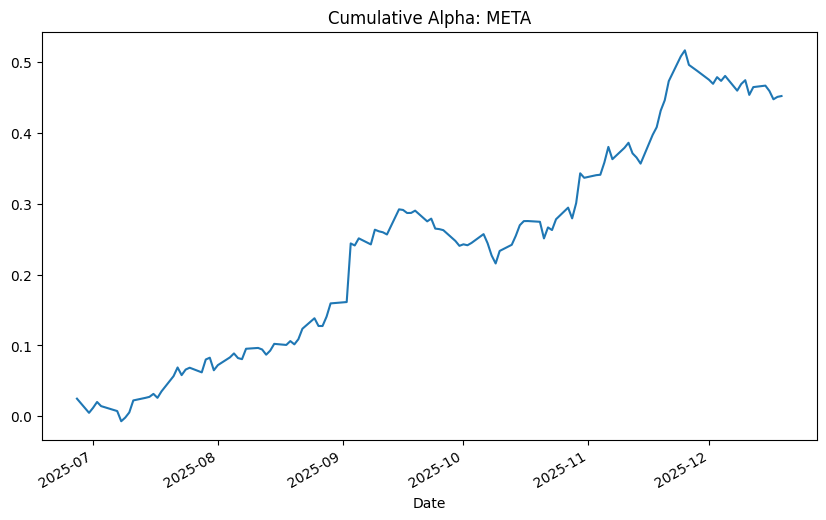

In [70]:
alpha_contr['GOOGL'].cumsum().plot(title='Cumulative Alpha: META', figsize=(10,6))